# 1. CLIP
CLIP은 이미지와 텍스트를 같은 의미 공간으로 정렬하기 위해 대비 학습(contrastive learning)을 사용하는 대표적인 Pretrained Vision–Language 모델입니다. 이미지 인코더와 텍스트 인코더를 각각 학습시킨 뒤, 올바른 이미지–텍스트 쌍은 임베딩 공간에서 가깝게, 관련 없는 쌍은 멀어지도록 학습함으로써 두 모달리티 간 의미적 대응 관계를 형성합니다. 이 구조 덕분에 별도의 태스크별 학습 없이도 텍스트로 정의한 클래스 설명만으로 이미지를 분류하는 zero-shot 분류가 가능하며, 이미지–텍스트 검색(Text-to-Image, Image-to-Text Retrieval)에 특히 강점을 보입니다. 다만 생성 능력은 없고, 주로 “이해와 정렬”에 초점이 맞춰진 모델이라는 특징을 가집니다. [논문](https://arxiv.org/pdf/2103.00020)

# 2. CLIP이 등장한 배경
기존 컴퓨터 비전 모델은 다음과 같은 한계를 가지고 있었습니다.

- 데이터셋마다 고정된 라벨 구조에 의존
- 새로운 클래스가 나오면 재학습 필요
- 현실 세계처럼 열린(open-world) 개념을 다루기 어려움

CLIP은 이러한 문제를 해결하기 위해, 웹에 존재하는 대규모 이미지–텍스트 쌍 데이터를 활용하여 “이미지는 언어로 설명될 수 있고, 언어는 이미지로 대응될 수 있다” 라는 가정 하에 학습된 모델입니다.

# 3. CLIP의 핵심 아이디어 (Contrastive Learning)
CLIP은 대비 학습(Contrastive Learning)을 사용합니다.

올바른 이미지–텍스트 쌍 → 임베딩 거리 가깝게
관계없는 이미지–텍스트 쌍 → 임베딩 거리 멀게

# 4. 모델 구조 (Architecture)
CLIP은 두 개의 독립된 인코더로 구성됩니다.

- Vision Encoder

CNN(ResNet) 또는 ViT

이미지를 하나의 벡터로 변환
- Text Encoder

Transformer

문장을 하나의 벡터로 변환

두 인코더의 출력은 같은 차원의 임베딩 공간에 존재하며, 코사인 유사도(cosine similarity)를 통해 비교됩니다.

# 5.  학습 방식 (Training Objective)
- 이미지 임베딩 ↔ 텍스트 임베딩 간 유사도 행렬 계산
- Softmax 기반 대칭적 cross-entropy loss 사용
Image → Text 방향
Text → Image 방향

이로 인해 CLIP은 이미지 검색. 텍스트 검색을 동시에 잘하는 구조가 됩니다.

# 6. Zero-shot Learning이 가능한 이유
CLIP의 가장 큰 특징은 Zero-shot Image Classification입니다. 방법은 매우 단순합니다.

- 분류하고 싶은 클래스들을 문장으로 표현
예: “a photo of a dog”, “a photo of a cat”
- 이미지 임베딩과 각 문장 임베딩의 유사도 계산
- 가장 유사한 문장을 클래스 예측으로 선택

👉 즉, 라벨 = 텍스트 프롬프트이 개념이 이후 LLM 기반 멀티모달 모델의 핵심 사고방식이 됩니다.

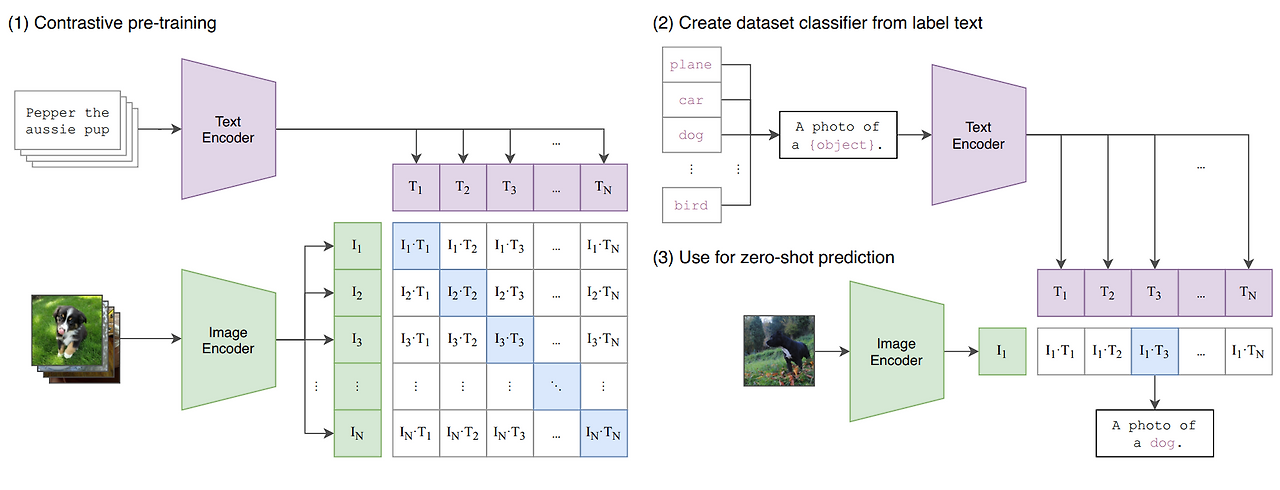